## 🧠 Tarea: Reconocimiento de Dígitos (OCR Básico)

### 📌 Objetivo

El objetivo de esta tarea es realizar un reconocedor de caracteres (OCR) básico capaz de reconocer los dígitos **0, 1, ..., 9** para una fuente específica.

Se cuenta con una imagen llamada **"C"** que contiene **900 subimágenes** (30 filas × 30 columnas), con **90 subimágenes por cada dígito**.

---

### 📂 Datos

La imagen `C` está disponible como:

```
N0123456789.png
```

Puedes descargarla en Colab con:

```python
!wget https://www.dropbox.com/scl/fi/7ohg9db762mxmgvjpudtr/N0123456789.png?rlkey=jlji7itekq079q1ohde7rmvc6
!mv N0123456789.png?rlkey=jlji7itekq079q1ohde7rmvc6 N0123456789.png
```

---

### 🔀 División de datos

* **Training:** primeras 27 columnas → 810 imágenes
* **Testing:** últimas 3 columnas → 90 imágenes
* Split: **90% entrenamiento / 10% testing**

---

### ⚠️ Importante

El código debe seguir los mismos pasos del ejemplo visto en clase (reconocimiento de ceros y unos).

---

## 🔧 Desarrollo

### 1. Lectura de imagen y Base de Datos

* Crear directorio `img`
* Guardar cada subimagen como archivo `.png`
* Formato de nombre:

```
img_dd_xxx.png
```

Donde:

* `dd` = dígito (00–09)
* `xxx` = número de muestra (001–090)

---

In [176]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from scipy import stats
import cv2 
import math
from sklearn.metrics import confusion_matrix

In [3]:
# Directory for the original images
!rm -rf 'img'
!mkdir img

In [4]:
I = plt.imread('N0123456789.png')

In [5]:
H, W = I.shape[:2]
h = H // 30
w = W // 30

for i in range(30):
    for j in range(30):
        c = i // 3
        t = (i % 3) * 30 + j + 1

        Iij = I[i*h:(i+1)*h, j*w:(j+1)*w]

        fimg = f'img/img_{c:02d}_{t:03d}.png'
        plt.imsave(fimg, Iij, cmap='gray')

In [6]:
#Verficiamos que estén todos
print(len(os.listdir('img')))

900


# 2. Extracción de Características

#### 2.0 Segmentación

* Crear directorio `seg`
* Guardar cada subimagen segmentada:

```
seg_dd_xxx.png
```

(array([  786.,    66.,    87.,    54.,    63.,    51.,    75.,    66.,
          114., 20270.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.90000004,
        1.        ]),
 <BarContainer object of 10 artists>)

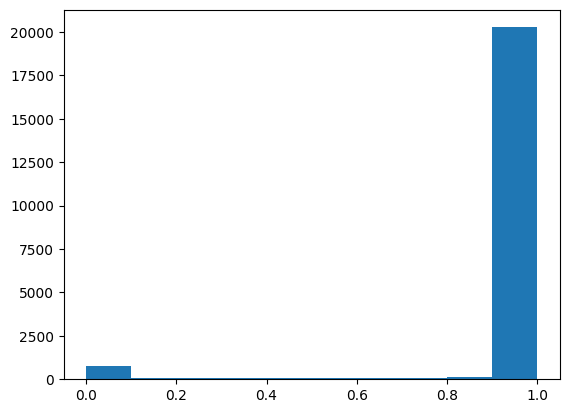

In [7]:
# Segmentación

I_seg = plt.imread('img/img_06_041.png')
plt.hist(np.array(I_seg).flatten())

In [12]:
# Ocupamos un threshold de 0.4 

!rm -rf 'seg'
!mkdir seg


In [13]:
"""
Prompt: Desarrolla un script en Python que realice una segmentación binaria por umbral
sobre un conjunto de imágenes contenidas en una lista de rutas predefinida.
El código debe cargar cada imagen en escala de grises y aplicar un umbral de 0.35,
asumiendo que los niveles de intensidad de los píxeles están normalizados en un rango de 0 a 1.
Es fundamental que el resultado booleano de la segmentación se escale al rango estándar
de 8 bits multiplicando por 255, asegurando así que las máscaras generadas sean visualmente
perceptibles y no aparezcan como imágenes negras al guardarse. Finalmente, el script debe
almacenar las máscaras resultantes en un directorio de salida específico, renombrando los
archivos originales de 'img_' a 'seg_' y manteniendo el formato PNG para evitar pérdida de datos
"""

if not os.path.exists('seg'):
    os.makedirs('seg')

archivos_originales = sorted([f for f in os.listdir('img') if f.endswith('.png')])

for nombre_archivo in archivos_originales:
    path_origen = os.path.join('img', nombre_archivo)
    
    with Image.open(path_origen) as img:
        # Tu lógica de binarización
        img_gray = img.convert('L')
        img_array = np.array(img_gray) / 255.0
        
        # Segmentación (Ubral 0.35)
        seg_array = (img_array < 0.35).astype(np.uint8) * 255
        seg_img = Image.fromarray(seg_array)

        # Guardamos con el nuevo prefijo 'seg_'
        nuevo_nombre = nombre_archivo.replace('img_', 'seg_')
        save_path = os.path.join('seg', nuevo_nombre)
        seg_img.save(save_path)

---

#### 2.1 Definición de Características

Definir características por separado, por ejemplo:

* Aspecto
* Área normalizada
* Número de agujeros
* ... hasta K características

#### 2.1.1 - Cantidad de Agujeros (Euler)

In [14]:
from skimage.measure import euler_number

def obtener_agujeros_euler(imagen):
    img_bin = imagen
    chi = euler_number(img_bin, connectivity=2)
    agujeros = 1 - chi
    
    return int(agujeros)



#### 2.1.2 Aspecto

In [15]:
### Sacado de Clases

# Aspecto

def Aspect(S,echo='off'):

  if len(S.shape)>2:
    S = S[:,:,0]

  # If image has multiple channels (RGBA), use the first one for segmentation
  R = S>0                 # Binary image of the segmentation

  # (i,j) coordinates of the pixels that belong to the region
  ij = np.argwhere(R)
  if len(ij) == 0:
      return 0

  ii = ij[:,0]
  jj = ij[:,1]

  # width
  w = np.max(jj)-np.min(jj)+1

  # height
  h = np.max(ii)-np.min(ii)+1

  # Aspect
  x = h/w

  if echo=='on':
    # Convert boolean to float/int to avoid Matplotlib dtype errors
    plt.imshow(R.astype(float), cmap='gray')
    print('height = '+str(h)+' pixels')
    print(' width = '+str(w)+' pixels')
    print('aspect = '+str(x))

  return x

#### 2.1.3 Área Normalizada

In [16]:
# Area Normalizada

def NormalizedArea(S,echo='off'):

  if len(S.shape)>2:
    S = S[:,:,0]

  # If image has multiple channels (RGBA), use the first one for segmentation
  R = S>0                 # Binary image of the segmentation


  Rf = fill_holes(R).astype(int) # filled region (with no holes)

  # Area
  A  = np.sum(R)
  Af = np.sum(Rf)


  # Normalized area
  if Af == 0: # Avoid division by zero if width or height is 0
      a = 0.0
  else:
      a = A/Af

  if echo=='on':
    implot = plt.imshow(R,cmap='gray')
    print('normalized area = '+str(a))
  return a

def fill_holes(binary_image):
    """
    Fill holes in a binary image.
    A hole is defined as a background region that is surrounded by foreground pixels.

    Parameters:
        binary_image (numpy.ndarray): A 2D binary NumPy array (0s and 1s).

    Returns:
        numpy.ndarray: Binary image with holes filled.
    """
    # Ensure input is binary (0 and 1 only)
    binary_image = (binary_image > 0).astype(np.uint8)

    # Create a padded version of the image to handle boundary cases
    padded = np.pad(binary_image, pad_width=1, mode='constant', constant_values=0)

    # Create a mask for background areas
    filled = np.zeros_like(padded, dtype=np.uint8)
    filled[0, 0] = 1  # Start flood-fill from the top-left corner

    # Structuring element for 4-connectivity (up, down, left, right)
    shifts = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    # Flood-fill algorithm
    while True:
        new_filled = filled.copy()
        for dx, dy in shifts:
            new_filled |= np.roll(filled, shift=dx, axis=0)
            new_filled |= np.roll(filled, shift=dy, axis=1)

        # Only allow propagation where the original padded image is background
        new_filled &= (padded == 0)

        if np.array_equal(filled, new_filled):
            break  # Stop when no new changes
        filled = new_filled

    # The holes are the complement of the flooded region inside the padded area
    holes_filled = np.where(filled[1:-1, 1:-1] == 0, 1, binary_image)

    return holes_filled

#### 2.1.4 Funciones Varias

In [17]:
# Otras funciones

def media_columna(X):
    return np.mean(np.sum(X,axis=0))

def media_fila(X):
    return np.mean(np.sum(X,axis=1))

def mediana_columna(X):
    return np.median(np.sum(X,axis=0))

def mediana_fila(X):
    return np.median(np.sum(X,axis=1))

def std_columna(X):
    return np.median(np.sum(X,axis=0))

def std_fila(X):
    return np.median(np.sum(X,axis=1))

def pix_sum(X):
    return np.sum(X)

#### 2.1.5 Zoning (Up-Down)

In [18]:
# Zoning Up-Down

def ZoningUD(imagen):
    mitad_fila = int(imagen.shape[0] / 2)
    suma_sup = np.sum(imagen[0:mitad_fila, :])
    suma_inf = np.sum(imagen[mitad_fila:, :])
    return suma_sup / suma_inf if suma_inf != 0 else 0.0

#### 2.1.6 Zoning Diagonal

In [19]:
def zoning_diag(imagen):
    img_bin = imagen.astype(np.float32)
    
    total_pixeles = np.sum(img_bin)
    
    if total_pixeles == 0:
        return 0.0

    h, w = img_bin.shape
    m_h, m_w = h // 2, w // 2

    sup_izq = np.sum(img_bin[:m_h, :m_w])
    inf_izq = np.sum(img_bin[m_h:, :m_w])
    
    return (sup_izq - inf_izq) / total_pixeles

---

#### 2.2 Extracción

* Construir matriz **X de tamaño 900 × K**
* Construir vector **Y de tamaño 900**

Donde:

* `Y[j] = d` si la subimagen `j` corresponde al dígito `d`

---

In [68]:
mis_filtros = [
    obtener_agujeros_euler,    # 0
    Aspect,        # 1
    NormalizedArea,    # 2
    media_columna,    # 3
    media_fila,   # 4
    mediana_columna, # 5
    mediana_fila, # 6
    std_columna, # 7
    std_fila, # 8
    pix_sum, # 9
    ZoningUD, # 10
    zoning_diag    # 11
]


In [49]:
archivos = sorted([f for f in os.listdir('seg/') if f.endswith('.png')])

X = np.zeros((900, len(mis_filtros)))
Y = np.zeros(900, dtype=int)

for j, nombre in enumerate(archivos):
    img = cv2.imread(f'seg/{nombre}', cv2.IMREAD_UNCHANGED)
    
    if img is not None:
        for i, funcion in enumerate(mis_filtros):
            X[j, i] = funcion(img)
        
    
        Y[j] = j // 90 



In [50]:
print(X.shape,Y.shape)

(900, 12) (900,)


In [51]:
valores, conteos = np.unique(Y, return_counts=True)

for v, c in zip(valores, conteos):
    print(f"{v}: {c} imágenes")

0: 90 imágenes
1: 90 imágenes
2: 90 imágenes
3: 90 imágenes
4: 90 imágenes
5: 90 imágenes
6: 90 imágenes
7: 90 imágenes
8: 90 imágenes
9: 90 imágenes


### 3. Selección de Características

* Elegir las características que mejor separen las clases
* Se pueden usar:

  * histogramas
  * gráficos en dimensiones similares
* La selección debe ser:

  * manual
  * basada en observación ("a ojo" o ensayo/error)

---

In [53]:
def obtener_listas_por_digito(matriz_X, columna_filtro):

    listas_por_digito = []
    
    for d in range(10):
        inicio = d * 90
        fin = (d + 1) * 90        
        valores_digito = matriz_X[inicio:fin, columna_filtro]
        
        listas_por_digito.append(valores_digito)
        
    return listas_por_digito


In [ ]:
agujeros = obtener_listas_por_digito(X, 0) 
area_normalizada = obtener_listas_por_digito(X,2)
media_columna = obtener_listas_por_digito(X,3)
x = obtener_listas_por_digito(X,10)
zon_di = obtener_listas_por_digito(X,11)

# Estas de arriba fueron las que me funcionaron finalmente, logicamente hice mas intentos, pero dejo la selección final por tema de orden


Máximos y Mínimos de c/ Distribución
0: 0.6236559139784946 0.6553911205073996
4: 0.8958333333333334 0.9239766081871345
6: 0.828125 0.8449612403100775
9: 0.8161209068010076 0.8341584158415841


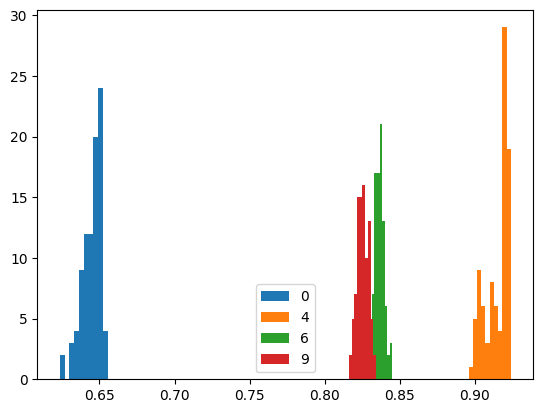

In [66]:
plt.hist(area_normalizada[0],label='0')
plt.hist(area_normalizada[4],label='4')
plt.hist(area_normalizada[6],label='6')
plt.hist(area_normalizada[9],label='9')

plt.legend()

print('Máximos y Mínimos de c/ Distribución')
print('0:',np.min(area_normalizada[0]),np.max(area_normalizada[0]))
print('4:',np.min(area_normalizada[4]),np.max(area_normalizada[4]))
print('6:',np.min(area_normalizada[6]),np.max(area_normalizada[6]))
print('9:',np.min(area_normalizada[9]),np.max(area_normalizada[9]))

Máximos y Mínimos de c/ Distribución
2: 688.9903846153846 745.3846153846154
3: 691.4423076923077 725.7692307692307
5: 713.5096153846154 772.3557692307693


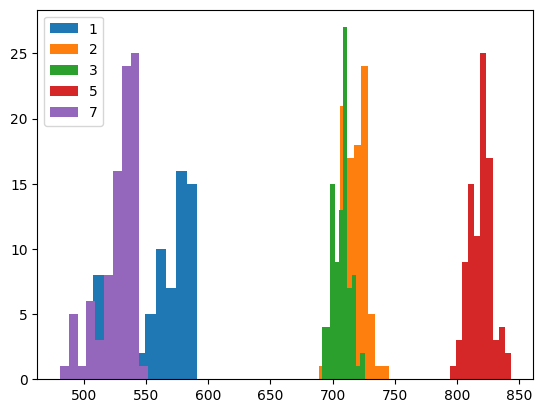

In [ ]:
plt.hist(media_columna[1],label='1')
plt.hist(media_columna[2],label='2')
plt.hist(media_columna[3],label='3')
plt.hist(media_columna[9],label='5')
plt.hist(media_columna[7],label='7')

plt.legend()

print('Máximos y Mínimos de c/ Distribución')
print('2:',np.min(media_columna[2]),np.max(media_columna[2]))
print('3:',np.min(media_columna[3]),np.max(media_columna[3]))

print('5:',np.min(media_columna[5]),np.max(media_columna[5]))

Máximos y Mínimos de c/ Distribución
1: 1.3529411764705883 1.536
7: 1.5384615384615385 1.7049180327868851


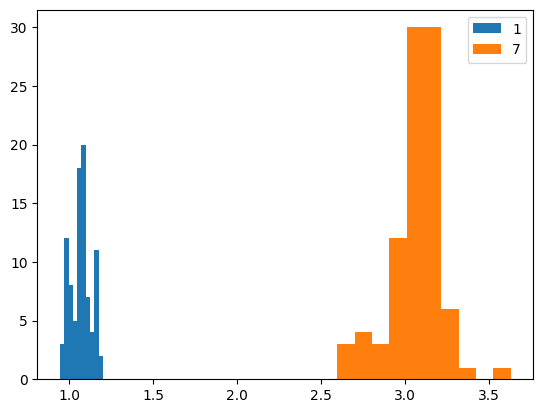

In [126]:
plt.hist(x[1],label='1')
plt.hist(x[7],label='7')

plt.legend()

print('Máximos y Mínimos de c/ Distribución')
print('1:',np.min(x[6]),np.max(x[6]))
print('7:',np.min(x[9]),np.max(x[9]))

Máximos y Mínimos de c/ Distribución
2: 1.2074074074074075 1.3412698412698412
3: 1.4782608695652173 1.6238532110091743


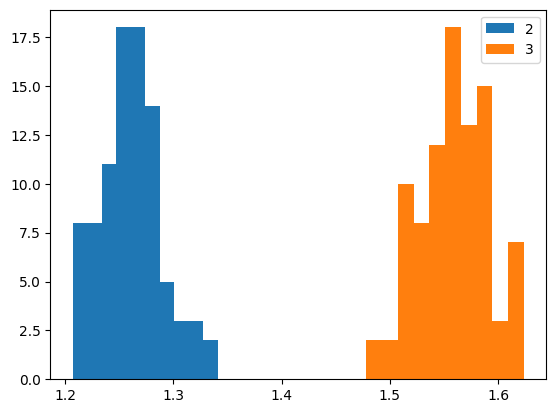

In [127]:
plt.hist(x[2],label='2')
plt.hist(x[3],label='3')

plt.legend()

print('Máximos y Mínimos de c/ Distribución')
print('2:',np.min(x[2]),np.max(x[2]))
print('3:',np.min(x[3]),np.max(x[3]))

Máximos y Mínimos de c/ Distribución
6: 1.3529411764705883 1.536
9: 1.5384615384615385 1.7049180327868851


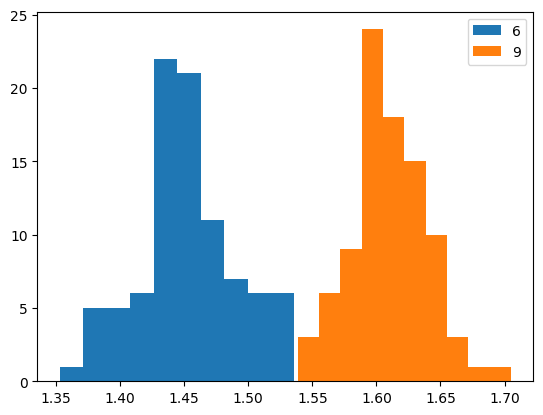

In [128]:
plt.hist(x[6],label='6')
plt.hist(x[9],label='9')

plt.legend()

print('Máximos y Mínimos de c/ Distribución')
print('6:',np.min(x[6]),np.max(x[6]))
print('9:',np.min(x[9]),np.max(x[9]))

Máximos y Mínimos de c/ Distribución
3: -0.017667844891548157 0.06896551698446274
5: 0.1164383590221405 0.20655737817287445


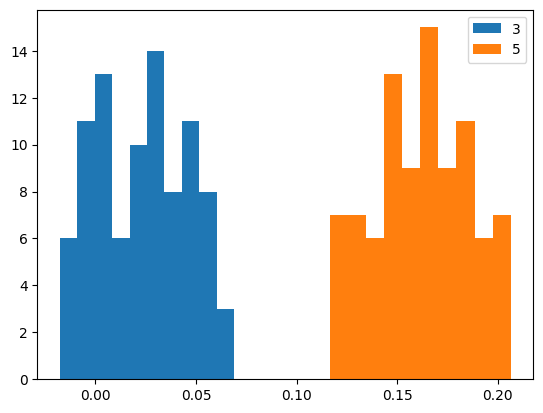

In [168]:
plt.hist(zon_di[3],label='3')
plt.hist(zon_di[5],label='5')

plt.legend()

print('Máximos y Mínimos de c/ Distribución')
print('3:',np.min(zon_di[3]),np.max(zon_di[3]))
print('5:',np.min(zon_di[5]),np.max(zon_di[5]))

#### - Con los agujeros podemos separar el [1,2,3,5,7] (0 agujeros) de [0,4,6,9] (1 agujero) del [8] (2 agujeros)
#### - Con el area normalizada puedo separar el el 0 y el 4 de [6,9]. 
#### - Con la media_columna podemos separar [1,2,3,5,7] en grupos dados por [1,7], [2,3,5]
#### - Con Zoning_UD se separa [1],[7] y [2]
#### - Con Zoning_Diag se separa [3] y [5]

### 4. Clasificación

Diseñar un algoritmo de clasificación.

Ejemplos de reglas:

* Si tiene 2 agujeros → puede ser 8
* Si tiene 1 agujero → puede ser 0, 4, 6, 9
* Si el agujero está abajo → puede ser 6

Clasificar las subfiguras de entrenamiento.

---

In [ ]:
#En base a las observaciones hechas en el inciso anterior se envió el sgte. Prompt

"""
Necesito que crees un algoritmo de clasificación en Python que reciba un vector de estas características y devuelva el dígito predicho (0-9) basado estrictamente en las siguientes reglas jerárquicas:

    Por Agujeros (Índice 0):

        Si tiene 2, es un 8.

        Si tiene 1, el grupo es [0, 4, 6, 9].

        Si tiene 0, el grupo es [1, 2, 3, 5, 7].

    Para el grupo de 1 agujero [0, 4, 6, 9]:

        Si NormalizedArea (Índice 2) < 0.7, es un 0.

        Si NormalizedArea (Índice 2) > 0.85, es un 4.

        Si está entre 0.7 y 0.85, evaluar ZoningUD (Índice 10): Si es > 1.537 es un 9, de lo contrario es un 6.

    Para el grupo de 0 agujeros [1, 2, 3, 5, 7]:

        Si media_columna (Índice 3) < 688, el subgrupo es [1, 7].

            Dentro de este subgrupo: Si ZoningUD (Índice 10) > 2.0 es un 7, de lo contrario es un 1.

        Si media_columna (Índice 3) >= 688:

            Usar zoning_diag (Índice 11): Si es > 0.09 es un 5.

            De lo contrario, evaluar ZoningUD (Índice 10): Si es > 1.4 es un 3, de lo contrario es un 2.

Por favor, genera la función clasificadora asegurándote de que los índices coincidan con la lista proporcionada.
"""

In [ ]:
def clasificador_digitos(vector_caracteristicas):
    # Mapeo de índices
    agujeros = vector_caracteristicas[0]
    area_norm = vector_caracteristicas[2]
    m_col = vector_caracteristicas[3]
    zoning_ud = vector_caracteristicas[10]
    zoning_diag = vector_caracteristicas[11] 

    # --- REGLA 1: Agujeros ---
    if agujeros == 2: 
        return 8
    
    elif agujeros == 1: # Caso [0, 4, 6, 9]
        if area_norm < 0.7:
            return 0
        elif area_norm > 0.85:
            return 4
        else:
            return 9 if zoning_ud > 1.537 else 6
                
    elif agujeros == 0: # Caso [1, 2, 3, 5, 7]
        # Primero separamos los más obvios por media de columna
        if m_col < 688: # Caso [1, 7]
            return 7 if zoning_ud > 2.0 else 1
        
        # --- EL CAMBIO CLAVE AQUÍ ---
        # Usamos tu nuevo descubrimiento: Zoning Diagonal para 3 vs 5
        # Según tu gráfico, el 5 SIEMPRE es mayor a 0.11
        if zoning_diag > 0.09: 
            return 5
        
        # Si no es 5, 1 o 7, queda decidir entre 2 y 3
        else:
            # Aquí puedes mantener tu regla de ZoningUD para separar el 2 del 3
            return 3 if zoning_ud > 1.4 else 2
                
    return -1



### 5. Evaluación

#### 5.1 Training

* Calcular:

  * Matriz de confusión
  * Accuracy → `Acc_train`

---

#### 5.2 Testing

* Aplicar el algoritmo a los datos de prueba
* Calcular:

  * Matriz de confusión
  * Accuracy → `Acc_test`

---



In [170]:
train_idx = []
test_idx = []

for i in range(10):
    inicio_bloque = i * 90
    
    indices_entrenamiento = range(inicio_bloque, inicio_bloque + 81)
    train_idx.extend(indices_entrenamiento)
    
    indices_prueba = range(inicio_bloque + 81, inicio_bloque + 90)
    test_idx.extend(indices_prueba)

train_idx = np.array(train_idx)
test_idx = np.array(test_idx)

In [171]:
X_train = X[train_idx, :]
Y_train = Y[train_idx]

X_test = X[test_idx, :]
Y_test = Y[test_idx]


In [ ]:
def prediccion(matriz_X):
    predicciones = []
    for i in range(matriz_X.shape[0]):
        res = clasificador_digitos(matriz_X[i, :])
        predicciones.append(res)
    return np.array(predicciones)

In [174]:
# Training 

Y_pred_train = prediccion(X_train)
acc_train = np.mean(Y_pred_train == Y_train) * 100
print(f"Precisión en Entrenamiento (Acc_train): {acc_train:.2f}%")


Precisión en Entrenamiento (Acc_train): 100.00%


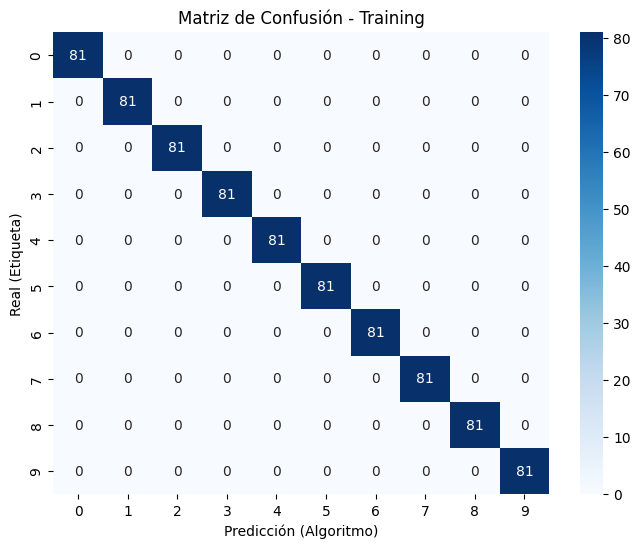

In [ ]:
# Generamos la matriz para el set de Training
cm = confusion_matrix(Y_train, Y_pred_train)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicción (Algoritmo)')
plt.ylabel('Real (Etiqueta)')
plt.title('Matriz de Confusión - Training')
plt.show()

In [175]:
# Testing

Y_pred_test = prediccion(X_test)
acc_test = np.mean(Y_pred_test == Y_test) * 100
print(f"Precisión en Testing (Acc_test): {acc_test:.2f}%")

Precisión en Testing (Acc_test): 100.00%


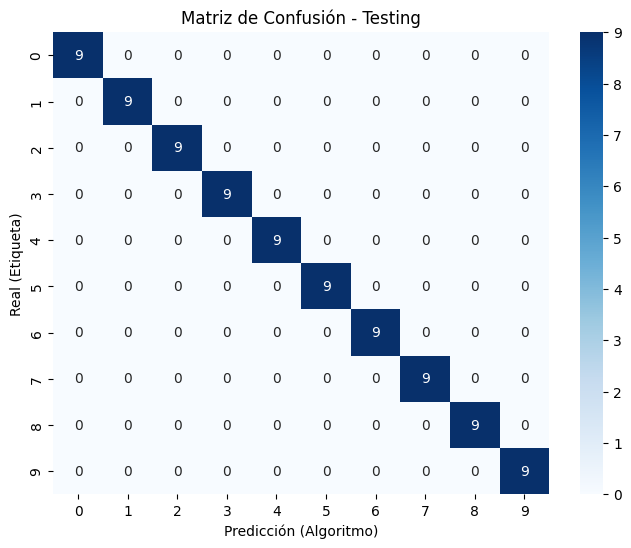

In [178]:
# Generamos la matriz para el set de Test
cm = confusion_matrix(Y_test, Y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicción (Algoritmo)')
plt.ylabel('Real (Etiqueta)')
plt.title('Matriz de Confusión - Testing')
plt.show()


### ⚠️ Consideración final

El algoritmo debe:

* Funcionar correctamente en estas imágenes
* Ser **robusto y generalizable**
* Evitar soluciones "hackeadas" o sobreajustadas

Ejemplo de mala práctica:

> "Si el pixel (27,45) < 34 entonces es un 1"

Se deben buscar soluciones **generales**, no específicas a los datos.